# Comparación visual de los modelos

Sobre test, con el protocolo de `compare_models.py` (IoU ≥ 0.3, 100 cajas por ventana, umbral
elegido en val): curvas precisión–recall, dónde vive el score de cada modelo, AP por clase y las
mismas 16 ventanas con las detecciones de cada uno en su punto de operación.

In [1]:
import sys
from pathlib import Path
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.transforms import ScaledTranslation
from torch import Tensor

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR / "src"))

from core.config import RUNS_DIR, P  # noqa: E402
from data import cache  # noqa: E402
from data.species import LabelSet  # noqa: E402
from evaluation.evaluator import ModelDumps, load_dumps, path_for  # noqa: E402
from evaluation.metrics import (  # noqa: E402
    MATCH_IOU,
    Boxes,
    PerClassAP,
    assignments,
    average_precision_per_class,
    detection_classes,
    mean_average_precision,
    overlaps,
)
from evaluation.protocol import (  # noqa: E402
    THRESHOLD_GRID,
    Matched,
    equalize,
    match,
    operating_point,
    select,
)
from utils.audio import mel_to_unit  # noqa: E402

RUNS = ["yolo26s_v2", "frcnn_v2", "detr_t10_logmel_v2", "detr_resnet", "detr_t10_pcen_v2"]
# Colores que no se confunden con el magma del espectrograma ni entre sí
COLORS = dict(zip(RUNS, ["#00b4d8", "#1e40af", "#22c55e", "#ff5fa2", "#f59e0b"], strict=True))
MIN_PRECISIONS = (0.70, 0.50)
MARKERS = dict(zip(MIN_PRECISIONS, ("o", "s"), strict=True))
ROWS, COLUMNS = 8, 2
SEED = 42
ANNOTATION_COLOR = "white"
CAPTION_BOX = {"facecolor": "black", "alpha": 0.55, "pad": 1.0, "lw": 0}
MARK_STEP_PT = 9  # separación entre los cuadraditos de acierto, en puntos
pd.set_option("display.width", 140)

In [2]:
class Evaluated(NamedTuple):
    dumps: ModelDumps
    test: Boxes  # predicciones de test igualadas, en orden de score
    matched: Matched
    thresholds: dict[float, float]  # precisión mínima en val -> umbral
    ap: PerClassAP


def evaluate(dumps: ModelDumps) -> Evaluated:
    matched_val = match(equalize(dumps.val.predictions), dumps.val.truth, dumps.val.n_images)
    thresholds = {}
    for min_precision in MIN_PRECISIONS:
        chosen = select(matched_val, min_precision)
        if chosen is not None:
            thresholds[min_precision] = chosen.threshold
    test = equalize(dumps.test.predictions)
    return Evaluated(
        dumps,
        test,
        match(test, dumps.test.truth, dumps.test.n_images),
        thresholds,
        average_precision_per_class(test, dumps.test.truth, len(dumps.test.labels)),
    )


paths = [path_for(RUNS_DIR / run, run, split) for run in RUNS for split in (cache.VAL, cache.TEST)]
models = {dumps.model: evaluate(dumps) for dumps in load_dumps(paths)}
reference = models[RUNS[0]].dumps.test
labels = LabelSet(reference.labels)
truth = reference.truth
detection = detection_classes(truth, len(labels))

summary = pd.DataFrame(
    [
        {
            "modelo": name,
            "mAP@0.3": mean_average_precision(m.ap, detection),
            **{f"umbral P≥{p:.2f}": m.thresholds.get(p) for p in MIN_PRECISIONS},
            **{
                f"{k} @P≥{MIN_PRECISIONS[0]:.2f}": getattr(
                    operating_point(m.matched, m.thresholds[MIN_PRECISIONS[0]]), k
                )
                for k in ("recall", "precision")
            },
        }
        for name, m in models.items()
    ]
).set_index("modelo")
print(f"test: {reference.n_images} ventanas · {len(truth.boxes)} cajas · IoU ≥ {MATCH_IOU}")
summary.round(3)

test: 7599 ventanas · 7924 cajas · IoU ≥ 0.3


,mAP@0.3,umbral P≥0.70,umbral P≥0.50,recall @P≥0.70,precision @P≥0.70
modelo,,,,,
yolo26s_v2,0.632,0.10,0.01,0.812,0.696
frcnn_v2,0.595,0.74,0.34,0.757,0.700
detr_t10_logmel_v2,0.589,0.31,0.21,0.773,0.700
detr_resnet,0.573,0.34,0.23,0.767,0.702
detr_t10_pcen_v2,0.545,0.31,0.18,0.748,0.687


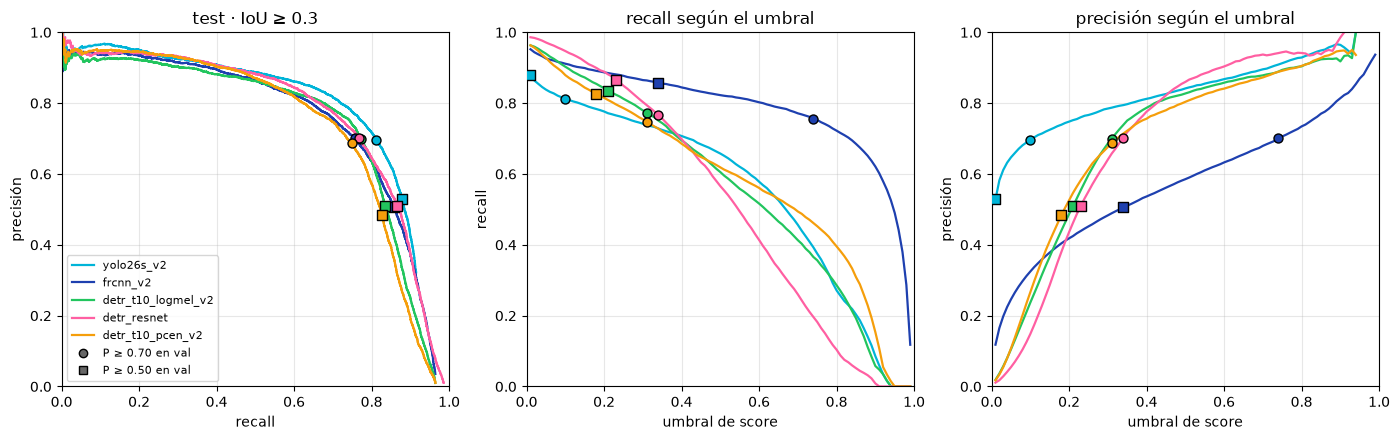

In [3]:
def pr_curve(matched: Matched) -> tuple[Tensor, Tensor]:
    # Toda la curva, una predicción por paso: más fina que la rejilla de umbrales.
    true_positives = matched.found.cumsum(0)
    return true_positives / matched.n_gt, true_positives / torch.arange(1, len(true_positives) + 1)


fig, (pr, by_recall, by_precision) = plt.subplots(1, 3, figsize=(17, 4.6))
for name, m in models.items():
    recall, precision = pr_curve(m.matched)
    pr.plot(recall, precision, color=COLORS[name], lw=1.6, label=name)
    grid = pd.DataFrame([operating_point(m.matched, t)._asdict() for t in THRESHOLD_GRID])
    by_recall.plot(grid.threshold, grid.recall, color=COLORS[name], lw=1.6)
    by_precision.plot(grid.threshold, grid.precision, color=COLORS[name], lw=1.6)
    for min_precision, threshold in m.thresholds.items():
        point = operating_point(m.matched, threshold)
        style = {"marker": MARKERS[min_precision], "color": COLORS[name], "ec": "black", "s": 42}
        pr.scatter(point.recall, point.precision, zorder=3, **style)
        by_recall.scatter(threshold, point.recall, zorder=3, **style)
        by_precision.scatter(threshold, point.precision, zorder=3, **style)
pr.set(xlabel="recall", ylabel="precisión", xlim=(0, 1), ylim=(0, 1))
pr.set_title(f"test · IoU ≥ {MATCH_IOU}")
by_recall.set(xlabel="umbral de score", ylabel="recall", xlim=(0, 1), ylim=(0, 1))
by_recall.set_title("recall según el umbral")
by_precision.set(xlabel="umbral de score", ylabel="precisión", xlim=(0, 1), ylim=(0, 1))
by_precision.set_title("precisión según el umbral")
handles = [
    *pr.get_legend_handles_labels()[0],
    *(
        Line2D(
            [], [], ls="", marker=MARKERS[p], color="#666", mec="black", label=f"P ≥ {p:.2f} en val"
        )
        for p in MIN_PRECISIONS
    ),
]
for ax in (pr, by_recall, by_precision):
    ax.grid(alpha=0.3)
pr.legend(handles=handles, fontsize=8, loc="lower left")
plt.show()

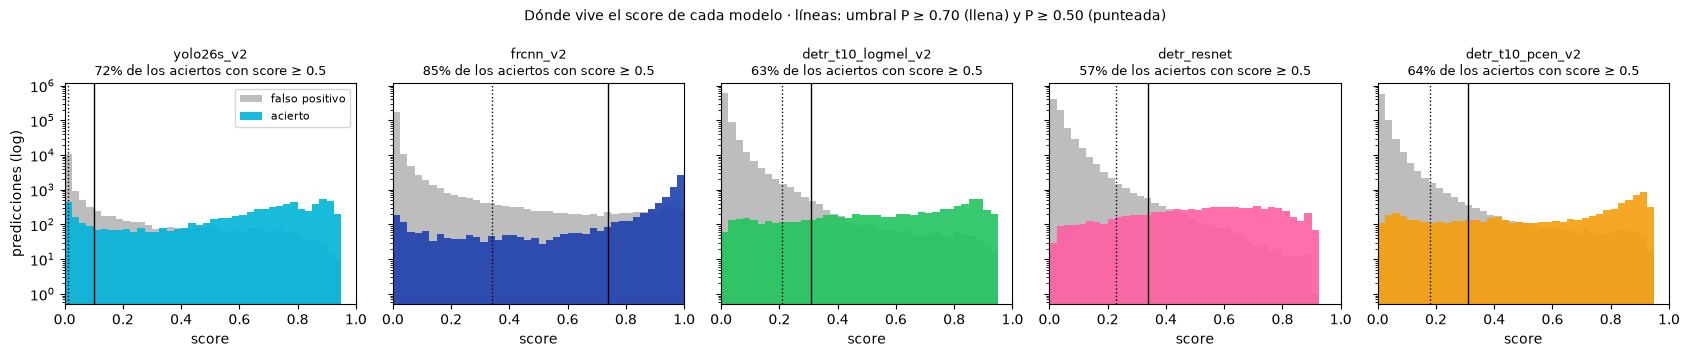

In [4]:
bins = np.linspace(0.0, 1.0, 41)
fig, axes = plt.subplots(1, len(models), figsize=(17, 3.6), sharey=True)
for ax, (name, m) in zip(axes, models.items(), strict=True):
    hit = m.matched.found == 1
    scores = m.test.scores
    ax.hist(scores[~hit], bins=bins, color="#bdbdbd", label="falso positivo")
    ax.hist(scores[hit], bins=bins, color=COLORS[name], alpha=0.9, label="acierto")
    for min_precision, threshold in m.thresholds.items():
        ax.axvline(
            threshold, color="black", lw=1.0, ls="-" if min_precision == MIN_PRECISIONS[0] else ":"
        )
    above_half = float((scores[hit] >= 0.5).float().mean())
    ax.set_title(f"{name}\n{above_half:.0%} de los aciertos con score ≥ 0.5", fontsize=9)
    ax.set(xlabel="score", yscale="log", xlim=(0, 1))
axes[0].set_ylabel("predicciones (log)")
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle(
    "Dónde vive el score de cada modelo · líneas: umbral P ≥ 0.70 (llena) y P ≥ 0.50 (punteada)",
    fontsize=10,
)
fig.tight_layout()
plt.show()

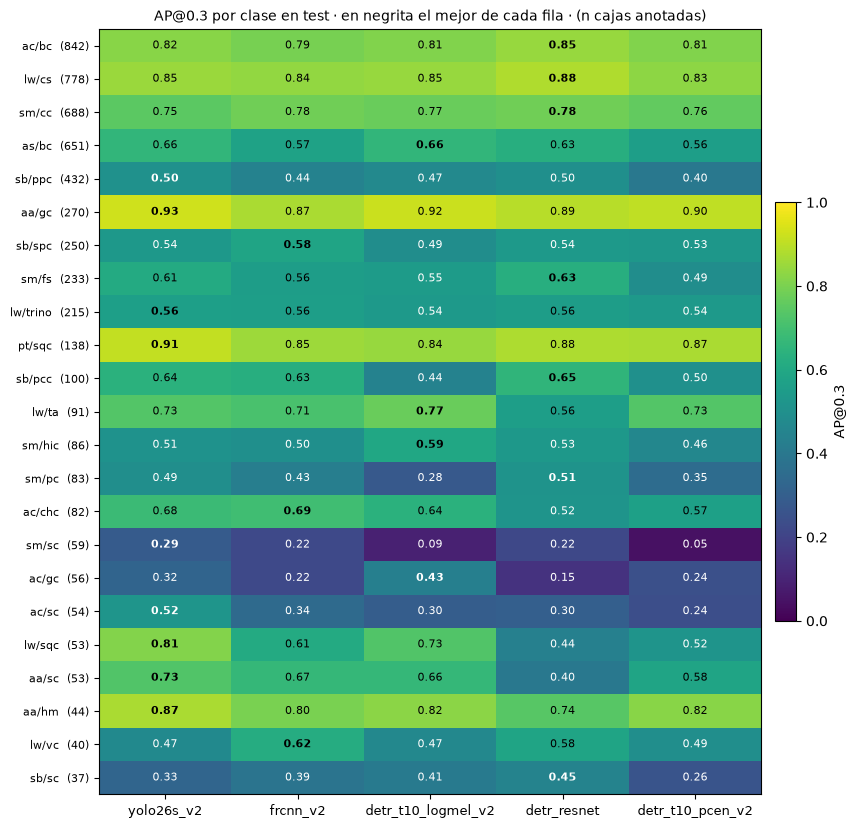

In [5]:
n_gt = pd.Series(truth.labels.long().tolist()).value_counts()
classes = [c for c in n_gt.index if c in detection]
ap_table = pd.DataFrame(
    {name: [m.ap[c] for c in classes] for name, m in models.items()},
    index=[f"{labels.name(c)}  ({int(n_gt[c])})" for c in classes],
).astype(float)

fig, ax = plt.subplots(figsize=(9, 0.38 * len(classes) + 1.2))
image = ax.imshow(ap_table.to_numpy(), cmap="viridis", vmin=0.0, vmax=1.0, aspect="auto")
best = ap_table.to_numpy().argmax(axis=1)
for (i, j), value in np.ndenumerate(ap_table.to_numpy()):
    ax.text(
        j,
        i,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=8,
        color="white" if value < 0.55 else "black",
        fontweight="bold" if j == best[i] else "normal",
    )
ax.set_xticks(range(len(models)), list(models), fontsize=9)
ax.set_yticks(range(len(classes)), ap_table.index, fontsize=8)
ax.set_title(
    "AP@0.3 por clase en test · en negrita el mejor de cada fila · (n cajas anotadas)", fontsize=10
)
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02, label="AP@0.3")
plt.show()

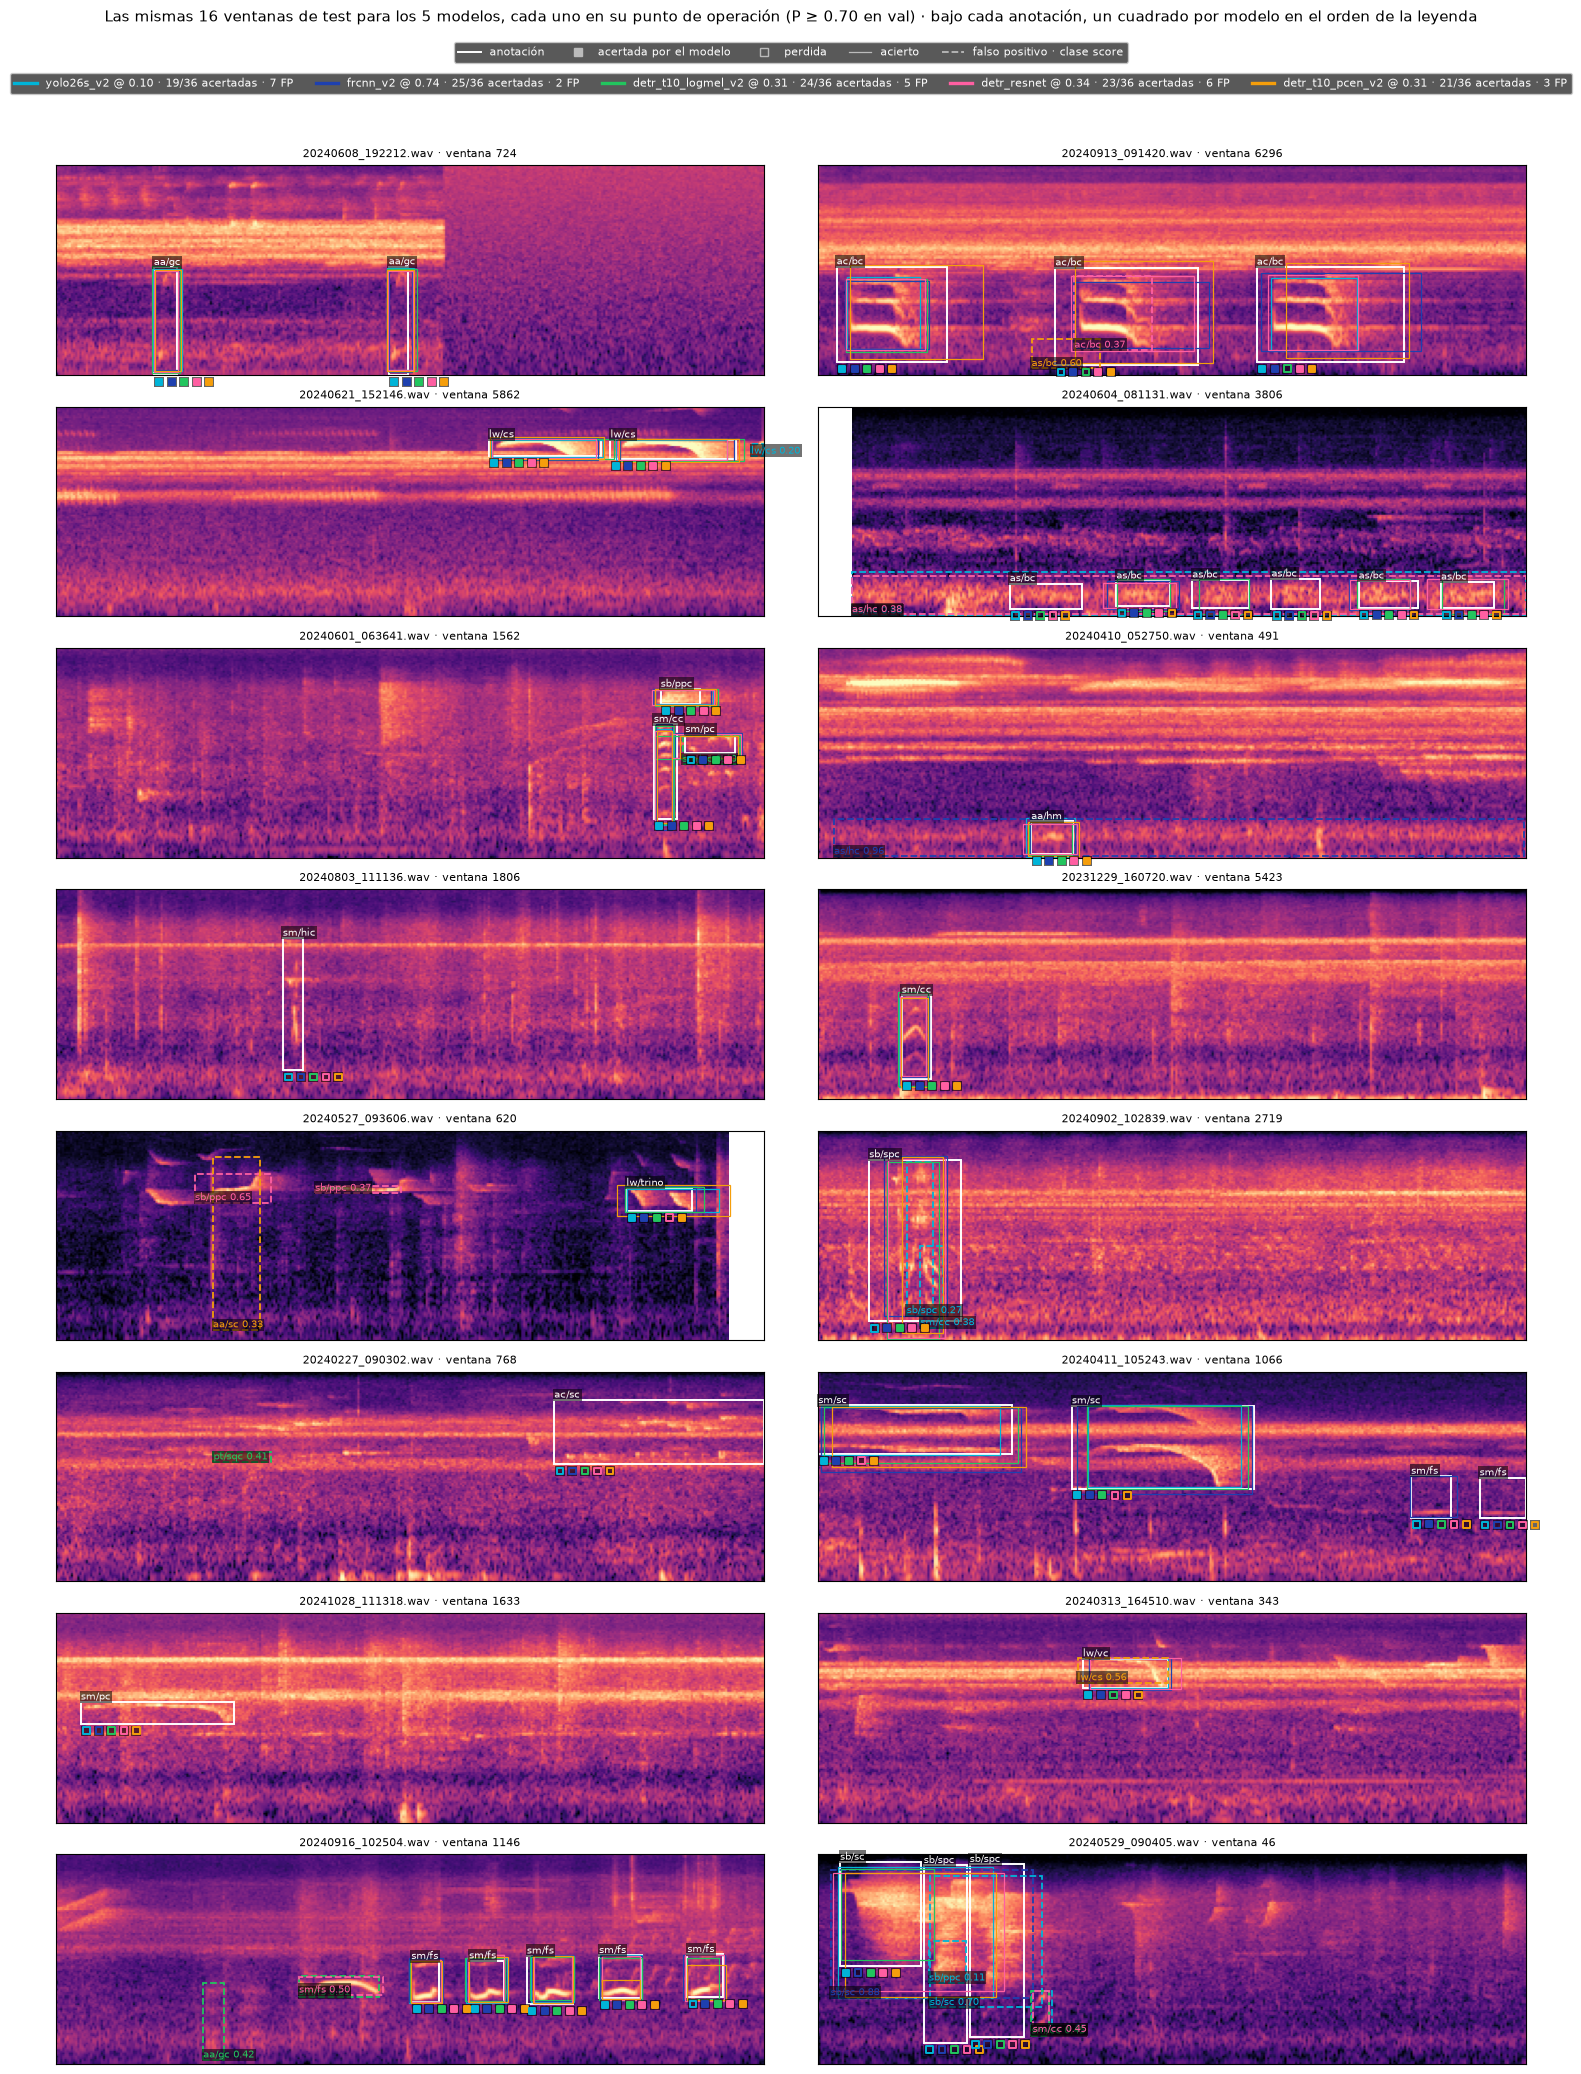

In [6]:
windows = torch.load(
    cache.split_path(cache.TEST), map_location="cpu", weights_only=False, mmap=True
)
db_low, db_high = cache.db_range()
sources = cache.sources(cache.TEST, reference.n_images)
# Fila anotada -> fila de la predicción que la acierta (la misma asignación que usa `hits`), y
# cuántas predicciones de cada modelo superan su propio punto de operación (P ≥ 0.70 en val).
paired = {
    name: {gt: row for row, gt in assignments(overlaps(m.test, truth, class_aware=True), MATCH_IOU)}
    for name, m in models.items()
}
shown = {name: m.matched.above(m.thresholds[MIN_PRECISIONS[0]]) for name, m in models.items()}


def pick_windows(n: int) -> list[int]:
    # Las mismas para todos los modelos: una por grabación, clases distintas mientras se pueda.
    boxes = pd.DataFrame(
        {"ventana": truth.image_ids.long().tolist(), "clase": truth.labels.long().tolist()}
    )
    boxes = boxes[boxes.clase.isin(detection)]
    boxes["grabación"] = [sources.recording_of_window[i] for i in boxes.ventana]
    candidates = (
        boxes.groupby("ventana")
        .first()
        .reset_index()
        .sample(frac=1.0, random_state=SEED)
        .drop_duplicates("grabación")
    )
    distinct = candidates.drop_duplicates("clase").ventana.tolist()
    rest = [w for w in candidates.ventana if w not in distinct]
    return (distinct + rest)[:n]


def rows_of(boxes: Boxes, image_id: int, limit: int | None = None) -> list[int]:
    ids = boxes.image_ids if limit is None else boxes.image_ids[:limit]
    return (ids == image_id).nonzero().flatten().tolist()


def found_by(name: str, gt_row: int) -> bool:
    return paired[name].get(gt_row, len(models[name].test.boxes)) < shown[name]


def rectangle(
    ax: Axes, box: Tensor, color: str, style: str, width: float, text: str = "", top: bool = True
) -> tuple[float, float]:
    cx, cy, w, h = box.tolist()
    x0, y0 = (cx - w / 2) * P.clip_len_s, cy - h / 2
    ax.add_patch(Rectangle((x0, y0), w * P.clip_len_s, h, fill=False, ec=color, ls=style, lw=width))
    if text:
        ax.text(
            x0, y0 + h if top else y0, text, color=color, fontsize=7, va="bottom", bbox=CAPTION_BOX
        )
    return x0, y0


def hit_marks(ax: Axes, x0: float, y0: float, gt_row: int) -> None:
    # Bajo la anotación, un cuadrado por modelo en el orden de la leyenda: lleno si la acertó.
    for k, name in enumerate(models):
        shift = ax.transData + ScaledTranslation(
            (4 + k * MARK_STEP_PT) / 72, -5 / 72, ax.figure.dpi_scale_trans
        )
        ax.scatter(
            [x0],
            [y0],
            s=46,
            marker="s",
            color="black",
            alpha=0.6,
            lw=0,
            transform=shift,
            clip_on=False,
            zorder=4,
        )
        ax.scatter(
            [x0],
            [y0],
            s=22,
            marker="s",
            facecolor=COLORS[name] if found_by(name, gt_row) else "none",
            edgecolor=COLORS[name],
            lw=1.4,
            transform=shift,
            clip_on=False,
            zorder=5,
        )


def draw_window(ax: Axes, image_id: int) -> None:
    image = mel_to_unit(windows["images"][image_id][0], db_low, db_high)
    ax.imshow(image, origin="lower", aspect="auto", cmap="magma", extent=(0, P.clip_len_s, 0, 1))
    for gt_row in rows_of(truth, image_id):
        name = labels.name(int(truth.labels[gt_row]))
        x0, y0 = rectangle(ax, truth.boxes[gt_row], ANNOTATION_COLOR, "-", 1.4, name)
        hit_marks(ax, x0, y0, gt_row)
    for name, m in models.items():
        for row in rows_of(m.test, image_id, shown[name]):
            if m.matched.found[row]:
                rectangle(ax, m.test.boxes[row], COLORS[name], "-", 0.9)
            else:
                caption = f"{labels.name(int(m.test.labels[row]))} {float(m.test.scores[row]):.2f}"
                rectangle(ax, m.test.boxes[row], COLORS[name], "--", 1.3, caption, top=False)
    ax.set(xticks=[], yticks=[])


def tally(name: str, chosen: list[int]) -> str:
    m = models[name]
    annotated = [gt_row for image_id in chosen for gt_row in rows_of(truth, image_id)]
    hits = sum(found_by(name, gt_row) for gt_row in annotated)
    false_positives = sum(
        int(m.matched.found[row] == 0)
        for image_id in chosen
        for row in rows_of(m.test, image_id, shown[name])
    )
    threshold = m.thresholds[MIN_PRECISIONS[0]]
    return f"{name} @ {threshold:.2f} · {hits}/{len(annotated)} acertadas · {false_positives} FP"


chosen = pick_windows(ROWS * COLUMNS)
fig, axes = plt.subplots(ROWS, COLUMNS, figsize=(15, 2.6 * ROWS))
for ax, image_id in zip(axes.flat, chosen, strict=True):
    draw_window(ax, image_id)
    recording = Path(sources.recordings[sources.recording_of_window[image_id]]).name
    ax.set_title(f"{recording} · ventana {image_id}", fontsize=8)
symbols = [
    Line2D([], [], color=ANNOTATION_COLOR, ls="-", lw=1.4, label="anotación"),
    Line2D(
        [],
        [],
        color="#bbb",
        ls="",
        marker="s",
        mfc="#bbb",
        mec="#bbb",
        label="acertada por el modelo",
    ),
    Line2D([], [], color="#bbb", ls="", marker="s", mfc="none", mec="#bbb", label="perdida"),
    Line2D([], [], color="#bbb", ls="-", lw=0.9, label="acierto"),
    Line2D([], [], color="#bbb", ls="--", lw=1.3, label="falso positivo · clase score"),
]
legend_style = {"loc": "upper center", "facecolor": "#303030", "labelcolor": "white", "fontsize": 8}
fig.suptitle(
    f"Las mismas {len(chosen)} ventanas de test para los {len(models)} modelos, cada uno en su punto de "
    f"operación (P ≥ {MIN_PRECISIONS[0]:.2f} en val) · bajo cada anotación, un cuadrado por modelo en el orden de la leyenda",
    fontsize=11,
    y=0.995,
)
fig.legend(handles=symbols, ncol=len(symbols), bbox_to_anchor=(0.5, 0.982), **legend_style)
fig.legend(
    handles=[Line2D([], [], color=COLORS[n], lw=2.4, label=tally(n, chosen)) for n in models],
    ncol=len(models),
    bbox_to_anchor=(0.5, 0.967),
    **legend_style,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()